# COMP6246 Machine Learning Technologies Coursework 2025/26
## Human Activity Recognition (HAR) – SO-Lively Dataset




### Section 0: Imports and Exploration

In [ ]:
# Necessary Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from sklearn.utils import class_weight
from matplotlib.patches import Patch



# Paths – relative to this notebook
DATA_DIR   = "D:\\MLT Coursework\\data"
TRAIN_PATH = os.path.join(DATA_DIR, "train")
TEST_PATH  = os.path.join(DATA_DIR, "test")

# Helper: load one subject (train by default, but can also load test)
def load_subject(subject_id, split="train"):
    if split == "train":
        folder = TRAIN_PATH
    elif split == "test":
        folder = TEST_PATH
    else:
        raise ValueError("split must be 'train' or 'test'")

    filepath = os.path.join(folder, f"{subject_id}.csv")
    return pd.read_csv(filepath)


In [2]:
df1 = load_subject("S006")
df2 = load_subject("S007")

In [3]:
# Checking if the data is loaded correctly
print("S006 label counts:")
print(df1["label"].value_counts())

print("\nS007 label counts:")
print(df2["label"].value_counts())

S006 label counts:
label
7      253029
6       62682
13      25040
1       24889
8       13036
3       12693
130     11290
14       3130
5        1550
4        1370
Name: count, dtype: int64

S007 label counts:
label
7     253029
6      62682
13     25040
1      24889
8      13036
3      12693
10     11290
14      3130
5       1550
4       1370
Name: count, dtype: int64


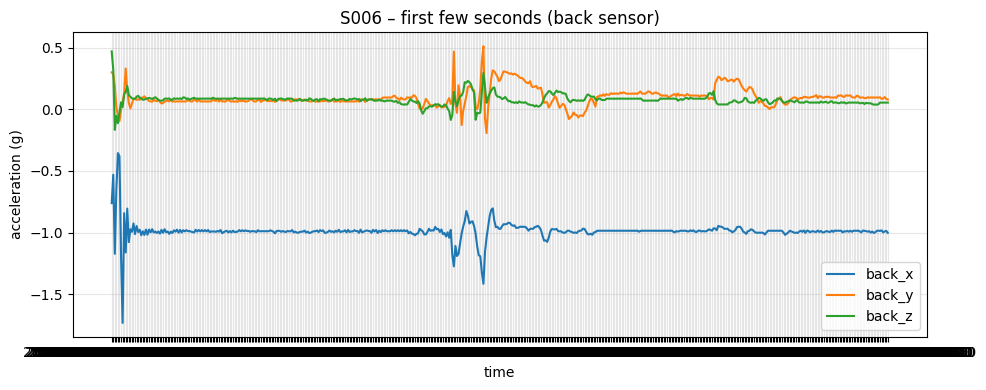

In [ ]:
sample = df1.iloc[:500]  # first 500 samples (~5 seconds if 100 Hz)

plt.figure(figsize=(10, 4))
plt.plot(sample["timestamp"], sample["back_x"], label="back_x")
plt.plot(sample["timestamp"], sample["back_y"], label="back_y")
plt.plot(sample["timestamp"], sample["back_z"], label="back_z")

plt.legend()
plt.title("S006 – first few seconds (back sensor)")
plt.xlabel("time")
plt.ylabel("acceleration (g)")
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

### Section 1 – Data Preprocessing
 Load full train and test dataset
<br>
Load and concatenate all subjects for a given split ('train' or 'test').


In [ ]:
def load_all_subjects(split="train"):
    if split == "train":
        folder = TRAIN_PATH
    elif split == "test":
        folder = TEST_PATH
    else:
        raise ValueError("split must be 'train' or 'test'")

    subjects = sorted([f for f in os.listdir(folder) if f.endswith(".csv")])
    df_list = []

    for file in subjects:
        filepath = os.path.join(folder, file)
        temp = pd.read_csv(filepath)

        # Subject ID for later analysis
        temp["subject"] = file.replace(".csv", "")

        df_list.append(temp)

    full_df = pd.concat(df_list, ignore_index=True)
    return full_df

# All TRAINING data (18 subjects: S006–S028)
full_df = load_all_subjects(split="train")
print("Training data shape (all train subjects):", full_df.shape)

# All TEST data (4 subjects: S010, S019, S021, S024)
test_df = load_all_subjects(split="test")
print("Test data shape (held-out subjects):", test_df.shape)

full_df.head()

Training data shape (all train subjects): (5568946, 11)
Test data shape (held-out subjects): (1122375, 10)


,timestamp,back_x,back_y,back_z,thigh_x,thigh_y,thigh_z,label,subject,index,Unnamed: 0
0,2019-01-12 00:00:00.000,-0.760242,0.299570,0.468570,-5.092732,-0.298644,0.709439,6,S006,NaN,NaN
1,2019-01-12 00:00:00.010,-0.530138,0.281880,0.319987,0.900547,0.286944,0.340309,6,S006,NaN,NaN
2,2019-01-12 00:00:00.020,-1.170922,0.186353,-0.167010,-0.035442,-0.078423,-0.515212,6,S006,NaN,NaN
3,2019-01-12 00:00:00.030,-0.648772,0.016579,-0.054284,-1.554248,-0.950978,-0.221140,6,S006,NaN,NaN
4,2019-01-12 00:00:00.040,-0.355071,-0.051831,-0.113419,-0.547471,0.140903,-0.653782,6,S006,NaN,NaN


Dropping unwanted columns

In [ ]:
cols_to_drop = ["index", "Unnamed: 0"]

def drop_unwanted_columns(df):
    return df.drop(
        columns=[c for c in cols_to_drop if c in df.columns],
        errors="ignore"
    )

full_df = drop_unwanted_columns(full_df)
test_df = drop_unwanted_columns(test_df)

print("Train columns:", full_df.columns.tolist())
print("Test  columns:", test_df.columns.tolist())
print("Train shape:", full_df.shape)
print("Test  shape:", test_df.shape)

Train columns: ['timestamp', 'back_x', 'back_y', 'back_z', 'thigh_x', 'thigh_y', 'thigh_z', 'label', 'subject']
Test  columns: ['timestamp', 'back_x', 'back_y', 'back_z', 'thigh_x', 'thigh_y', 'thigh_z', 'label', 'subject']
Train shape: (5568946, 9)
Test  shape: (1122375, 9)


In [7]:
full_df.columns
full_df.head()

,timestamp,back_x,back_y,back_z,thigh_x,thigh_y,thigh_z,label,subject
0,2019-01-12 00:00:00.000,-0.760242,0.299570,0.468570,-5.092732,-0.298644,0.709439,6,S006
1,2019-01-12 00:00:00.010,-0.530138,0.281880,0.319987,0.900547,0.286944,0.340309,6,S006
2,2019-01-12 00:00:00.020,-1.170922,0.186353,-0.167010,-0.035442,-0.078423,-0.515212,6,S006
3,2019-01-12 00:00:00.030,-0.648772,0.016579,-0.054284,-1.554248,-0.950978,-0.221140,6,S006
4,2019-01-12 00:00:00.040,-0.355071,-0.051831,-0.113419,-0.547471,0.140903,-0.653782,6,S006


1.1 Class balance (before cleaning)

TRAIN set class distribution BEFORE cleaning:
label
1       766811
2       238342
3       212676
4        59987
5        56349
6       634355
7      2732508
8       358012
10       11290
13      392473
14       58383
130      39895
140       7865
Name: count, dtype: int64

TEST set class distribution BEFORE cleaning:
label
1      333773
2       35240
3       49154
4       17214
5       11518
6      159630
7      419818
8       79080
13      16087
14        561
130       300
Name: count, dtype: int64


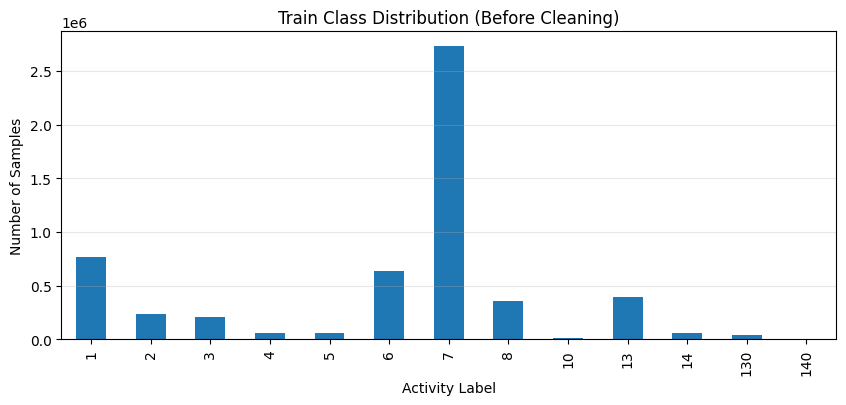

In [ ]:
print("TRAIN set class distribution BEFORE cleaning:")
class_counts_train_before = full_df["label"].value_counts().sort_index()
print(class_counts_train_before)

print("\nTEST set class distribution BEFORE cleaning:")
class_counts_test_before = test_df["label"].value_counts().sort_index()
print(class_counts_test_before)

plt.figure(figsize=(10, 4))
class_counts_train_before.plot(kind="bar")
plt.title("Train Class Distribution (Before Cleaning)")
plt.xlabel("Activity Label")
plt.ylabel("Number of Samples")
plt.grid(axis="y", alpha=0.3)
plt.show()

Dropping Cycling Activities

Original TRAIN dataset size: (5568946, 9)
Original TEST  dataset size: (1122375, 9)

After dropping cycling:
TRAIN size: (5070330, 9)
TEST  size: (1105427, 9)

TRAIN class distribution AFTER dropping cycling:
label
1      766811
2      238342
3      212676
4       59987
5       56349
6      634355
7     2732508
8      358012
10      11290
Name: count, dtype: int64


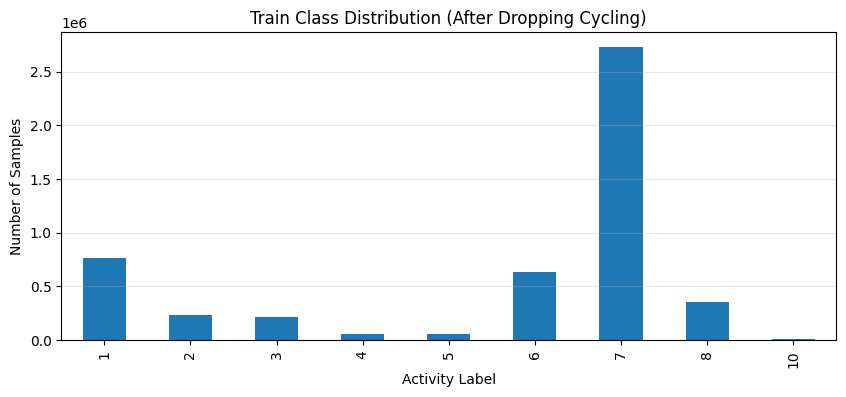

In [ ]:
CYCLING_LABELS = [13, 14, 130, 140]

def drop_cycling(df):
    return df[~df["label"].isin(CYCLING_LABELS)].copy()

print("Original TRAIN dataset size:", full_df.shape)
print("Original TEST  dataset size:", test_df.shape)

full_df = drop_cycling(full_df)
test_df = drop_cycling(test_df)

print("\nAfter dropping cycling:")
print("TRAIN size:", full_df.shape)
print("TEST  size:", test_df.shape)

class_counts_train_after = full_df["label"].value_counts().sort_index()
print("\nTRAIN class distribution AFTER dropping cycling:")
print(class_counts_train_after)

plt.figure(figsize=(10, 4))
class_counts_train_after.plot(kind="bar")
plt.title("Train Class Distribution (After Dropping Cycling)")
plt.xlabel("Activity Label")
plt.ylabel("Number of Samples")
plt.grid(axis="y", alpha=0.3)
plt.show()

1.3 Merge stairs ascending/descending

Dataset size after stairs merge (TRAIN): (5070330, 9)
Dataset size after stairs merge (TEST): (1105427, 9)

TRAIN class distribution AFTER dropping cycling + merging stairs:
label
1      766811
2      238342
3      212676
6      634355
7     2732508
8      358012
9      116336
10      11290
Name: count, dtype: int64


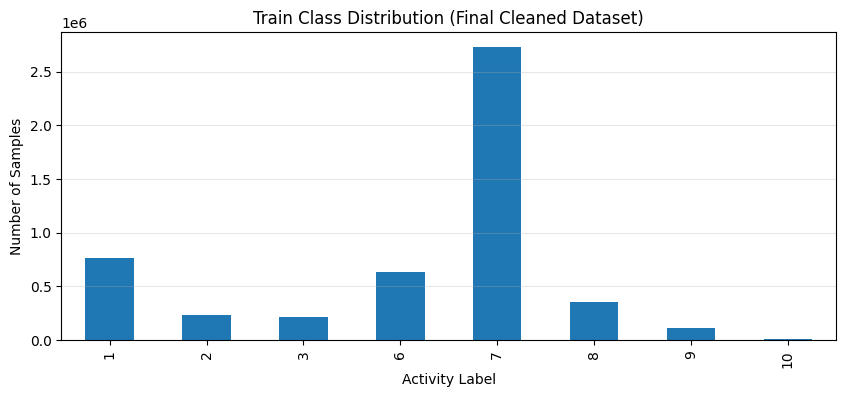

In [ ]:
# Merging labels 4 and 5 into a single stairs class with code 9.
def merge_stairs(df):
    df = df.copy()
    df.loc[df["label"].isin([4, 5]), "label"] = 9
    return df

# Apply to BOTH train and test
full_df = merge_stairs(full_df)
test_df = merge_stairs(test_df)

print("Dataset size after stairs merge (TRAIN):", full_df.shape)
print("Dataset size after stairs merge (TEST):", test_df.shape)

class_counts_final_train = full_df["label"].value_counts().sort_index()
print("\nTRAIN class distribution AFTER dropping cycling + merging stairs:")
print(class_counts_final_train)

plt.figure(figsize=(10, 4))
class_counts_final_train.plot(kind="bar")
plt.title("Train Class Distribution (Final Cleaned Dataset)")
plt.xlabel("Activity Label")
plt.ylabel("Number of Samples")
plt.grid(axis="y", alpha=0.3)
plt.show()

1.4 Exploration of Walking Class(Important)

According to Coursework Document our requirement was to- 
Use appropriate sampling and visualisations to report and interpret data patterns of the Walking class

In [ ]:
# Extracting walking class after cleaning
walking_df = full_df[full_df["label"] == 1].copy()

print("Walking samples (TRAIN only):", walking_df.shape)
walking_df.head()

Walking samples (TRAIN only): (766811, 9)


,timestamp,back_x,back_y,back_z,thigh_x,thigh_y,thigh_z,label,subject
46,2019-01-12 00:00:00.460,-0.979810,0.064414,0.096672,-0.923951,0.028942,-0.275996,1,S006
47,2019-01-12 00:00:00.470,-0.988628,0.062305,0.094441,-0.997658,0.039747,-0.286079,1,S006
48,2019-01-12 00:00:00.480,-0.979188,0.065592,0.083119,-0.950199,0.059354,-0.286677,1,S006
49,2019-01-12 00:00:00.490,-0.987749,0.072967,0.088315,-0.996941,0.068661,-0.272558,1,S006
50,2019-01-12 00:00:00.500,-0.986095,0.069343,0.077932,-0.924641,0.043127,-0.309695,1,S006


Plotting a Time-Series Window of Walking

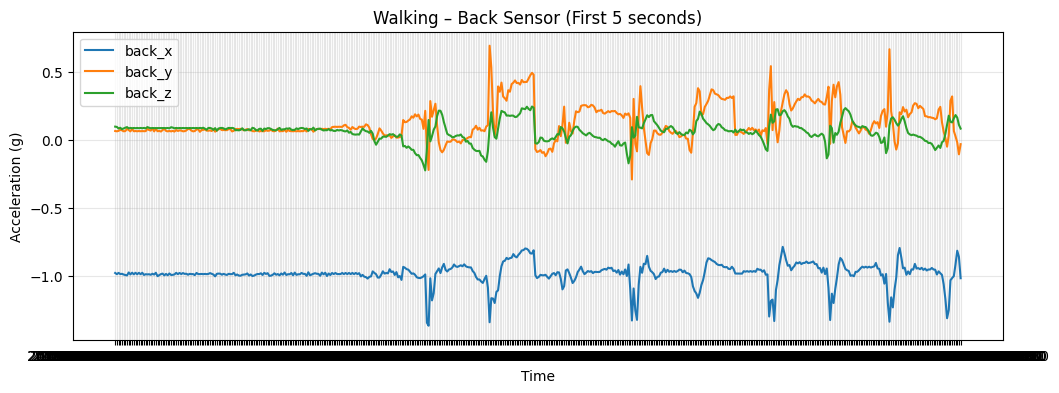

In [ ]:
# We take a 5-second walking slice (~500 samples)
walking_segment = walking_df.iloc[:500]

plt.figure(figsize=(12,4))
plt.plot(walking_segment["timestamp"], walking_segment["back_x"], label="back_x")
plt.plot(walking_segment["timestamp"], walking_segment["back_y"], label="back_y")
plt.plot(walking_segment["timestamp"], walking_segment["back_z"], label="back_z")
plt.legend()
plt.title("Walking – Back Sensor (First 5 seconds)")
plt.xlabel("Time")
plt.ylabel("Acceleration (g)")
plt.grid(alpha=0.3)
plt.show()

Compute ENMO (Movement) for Walking

In [13]:
# Compute ENMO (movement) for both sensors, for WALKING ONLY (exploration)

walking_df = walking_df.copy()

walking_df["enmo_back"] = (
    np.sqrt(
        walking_df["back_x"]**2 +
        walking_df["back_y"]**2 +
        walking_df["back_z"]**2
    ) - 1.0
).clip(lower=0)

walking_df["enmo_thigh"] = (
    np.sqrt(
        walking_df["thigh_x"]**2 +
        walking_df["thigh_y"]**2 +
        walking_df["thigh_z"]**2
    ) - 1.0
).clip(lower=0)

walking_df[["enmo_back", "enmo_thigh"]].describe()

,enmo_back,enmo_thigh
count,766811.000000,766811.000000
mean,0.133217,0.359253
std,0.236291,0.608389
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.076146
75%,0.183843,0.520738
max,4.368595,21.714693


### Section 2: Data Cleaning and Preparation

2.1: Analysis of S007 Dataset


In [ ]:
s007 = load_subject("S007", split="train")

cols_to_keep = ["timestamp", "back_x", "back_y", "back_z",
                "thigh_x", "thigh_y", "thigh_z", "label"]

s007 = s007[[col for col in s007.columns if col in cols_to_keep]].copy()

s007.head(), s007.shape

(                 timestamp    back_x    back_y    back_z   thigh_x   thigh_y  \
 0  2019-01-17 00:00:00.000 -0.722229  0.284592  0.445141 -4.838095 -0.283712   
 1  2019-01-17 00:00:00.010 -0.503632  0.267786  0.303988  0.855520  0.272597   
 2  2019-01-17 00:00:00.020 -1.112376  0.177035 -0.158659 -0.033670 -0.074502   
 3  2019-01-17 00:00:00.030 -0.616333  0.015750 -0.051570 -1.476536 -0.903429   
 4  2019-01-17 00:00:00.040 -0.337317 -0.049239 -0.107748 -0.520097  0.133858   
 
     thigh_z  label  
 0  0.673967      6  
 1  0.323293      6  
 2 -0.489452      6  
 3 -0.210083      6  
 4 -0.621093      6  ,
 (408709, 8))

In [15]:
#   Check for Incorrect Labels specifically for label 10 which is fed to S007 deliberately
print("Unique labels in S007:")
print(sorted(s007["label"].unique()))

Unique labels in S007:
[np.int64(1), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(13), np.int64(14)]


In [16]:
#  Check for Timestamp Irregularities
s007["timestamp"] = pd.to_datetime(s007["timestamp"])
s007["delta"] = s007["timestamp"].diff()

print(s007["delta"].value_counts().head(20))

delta
0 days 00:00:00.010000    408670
0 days 00:00:01.630000         2
0 days 00:00:00.550000         2
0 days 00:00:01.430000         2
0 days 00:00:01.870000         2
0 days 00:00:00.630000         1
0 days 00:00:00.510000         1
0 days 00:00:01.410000         1
0 days 00:00:01.190000         1
0 days 00:00:05.030000         1
0 days 00:00:03.250000         1
0 days 00:00:01.270000         1
0 days 00:00:05.120000         1
0 days 00:00:01.810000         1
0 days 00:00:02.410000         1
0 days 00:00:00.990000         1
0 days 00:00:04.940000         1
0 days 00:00:02.250000         1
0 days 00:00:01.010000         1
0 days 00:00:17.690000         1
Name: count, dtype: int64


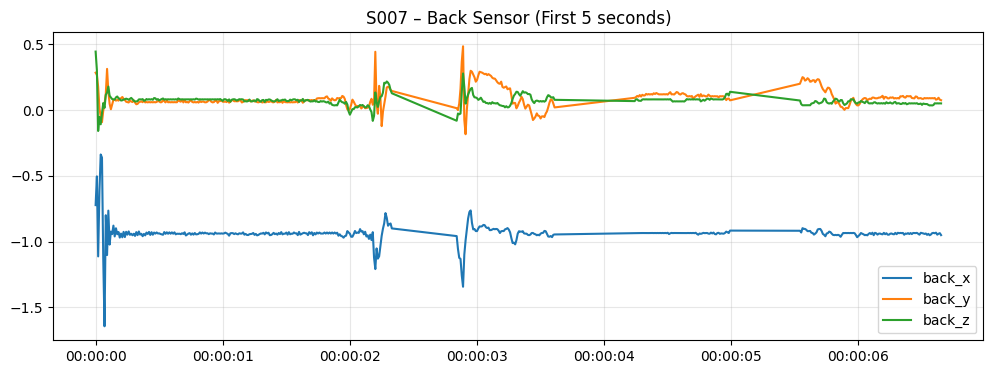

In [17]:
# Visualise Signals for Quality Issues
sample = s007.iloc[:500]

plt.figure(figsize=(12,4))
plt.plot(sample["timestamp"], sample["back_x"], label="back_x")
plt.plot(sample["timestamp"], sample["back_y"], label="back_y")
plt.plot(sample["timestamp"], sample["back_z"], label="back_z")
plt.legend()
plt.title("S007 – Back Sensor (First 5 seconds)")
plt.grid(alpha=0.3)
plt.show()

2.2: S007 Cleaning
<br>
For Subject S007, I identified corrupted segments caused by irregular timestamp gaps and an invalid label value (10). Based on this, I applied a targeted deletion strategy, removing only the rows within ±15 samples of each detected anomaly. I chose deletion instead of imputation because the corrupted segments were short, inconsistent, and not reliably recoverable. This approach improves data quality while keeping almost all of S007’s valid data, resulting in only a small reduction in overall dataset size.

In [18]:
def clean_s007_rows(df):
    df = df.copy()

    mask_s007 = df["subject"] == "S007"
    s007 = df[mask_s007].copy()

    # Convert timestamp and compute delta
    s007["timestamp"] = pd.to_datetime(s007["timestamp"])
    s007["delta"] = s007["timestamp"].diff()

    expected_step = pd.Timedelta(milliseconds=10)  # 0.01 s sampling

    # A) Invalid label 10
    bad_label = s007["label"] == 10

    # B) Irregular sampling (timestamp jumps)
    bad_delta = s007["delta"] != expected_step

    # Build indices to drop in original df
    to_drop = set()

    # Drop all label 10 rows
    to_drop.update(s007.index[bad_label])

    # Drop a small window around each irregular delta
    window = 50 
    for idx in s007.index[bad_delta]:
        start = idx - window
        end   = idx + window
        for i in range(start, end + 1):
            to_drop.add(i)

    print("Total S007 rows to drop from train:", len(to_drop))

    df_clean = df.drop(index=list(to_drop), errors="ignore").reset_index(drop=True)
    return df_clean


print("TRAIN size BEFORE S007 cleaning:", full_df.shape)
full_df = clean_s007_rows(full_df)
print("TRAIN size AFTER  S007 cleaning:", full_df.shape)

TRAIN size BEFORE S007 cleaning: (5070330, 9)
Total S007 rows to drop from train: 15804
TRAIN size AFTER  S007 cleaning: (5055206, 9)


In [19]:
# ENMO FEATURES FOR ALL SUBJECTS (TRAIN + TEST) 
def add_enmo_features(df):
    df = df.copy()
    df["back_enmo"] = (
        np.sqrt(df["back_x"]**2 + df["back_y"]**2 + df["back_z"]**2) - 1.0
    ).clip(lower=0)

    df["thigh_enmo"] = (
        np.sqrt(df["thigh_x"]**2 + df["thigh_y"]**2 + df["thigh_z"]**2) - 1.0
    ).clip(lower=0)

    return df

full_df = add_enmo_features(full_df)
test_df = add_enmo_features(test_df)

full_df.head()

,timestamp,back_x,back_y,back_z,thigh_x,thigh_y,thigh_z,label,subject,back_enmo,thigh_enmo
0,2019-01-12 00:00:00.000,-0.760242,0.299570,0.468570,-5.092732,-0.298644,0.709439,6,S006,0.000000,4.150574
1,2019-01-12 00:00:00.010,-0.530138,0.281880,0.319987,0.900547,0.286944,0.340309,6,S006,0.000000,0.004556
2,2019-01-12 00:00:00.020,-1.170922,0.186353,-0.167010,-0.035442,-0.078423,-0.515212,6,S006,0.197363,0.000000
3,2019-01-12 00:00:00.030,-0.648772,0.016579,-0.054284,-1.554248,-0.950978,-0.221140,6,S006,0.000000,0.835470
4,2019-01-12 00:00:00.040,-0.355071,-0.051831,-0.113419,-0.547471,0.140903,-0.653782,6,S006,0.000000,0.000000


2.3 : Windowing

In [ ]:
# WINDOWING: 2s WINDOW, 1s OVERLAP

WINDOW_SECONDS = 2
OVERLAP_SECONDS = 1
SAMPLING_RATE = 10          # 0.1 s between timestamps
WINDOW_SIZE = WINDOW_SECONDS * SAMPLING_RATE   # 20 samples
STEP_SIZE   = (WINDOW_SECONDS - OVERLAP_SECONDS) * SAMPLING_RATE  # 10 samples

FEATURE_CHANNELS = [
    "back_x", "back_y", "back_z",
    "thigh_x", "thigh_y", "thigh_z",
    "back_enmo", "thigh_enmo",
]

def create_windows_for_subject(df_sub):
    values = df_sub[FEATURE_CHANNELS].values
    labels = df_sub["label"].values
    n = len(df_sub)

    X_list, y_list, meta_list = [], [], []

    start = 0
    while start + WINDOW_SIZE <= n:
        end = start + WINDOW_SIZE
        window_data = values[start:end]
        window_labels = labels[start:end]

        # Majority label in the window
        unique, counts = np.unique(window_labels, return_counts=True)
        majority_label = unique[np.argmax(counts)]

        X_list.append(window_data)
        y_list.append(majority_label)
        meta_list.append({
            "subject": df_sub["subject"].iloc[0],
            "start_idx": start,
            "end_idx": end
        })

        start += STEP_SIZE

    if not X_list:
        return None, None, None

    X_sub = np.stack(X_list)
    y_sub = np.array(y_list)
    meta_sub = pd.DataFrame(meta_list)
    return X_sub, y_sub, meta_sub


def create_windows(df):
    X_all, y_all, meta_all = [], [], []

    # Sorting by subject + timestamp
    df_sorted = df.sort_values(["subject", "timestamp"]).reset_index(drop=True)

    for subject_id, df_sub in df_sorted.groupby("subject"):
        X_sub, y_sub, meta_sub = create_windows_for_subject(df_sub)
        if X_sub is None:
            continue
        X_all.append(X_sub)
        y_all.append(y_sub)
        meta_all.append(meta_sub)

    X = np.concatenate(X_all, axis=0)
    y = np.concatenate(y_all, axis=0)
    meta = pd.concat(meta_all, ignore_index=True)
    return X, y, meta


# Applying windowing to TRAIN and TEST
X_train_full, y_train_full, meta_train = create_windows(full_df)
X_test,       y_test,       meta_test  = create_windows(test_df)

X_train_full.shape, X_test.shape

((505494, 20, 8), (110537, 20, 8))

In [ ]:
# TRAIN / VALIDATION SPLIT (WINDOW LEVEL)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full,
)

X_train.shape, X_val.shape, y_train.shape, y_val.shape

((404395, 20, 8), (101099, 20, 8), (404395,), (101099,))

In [ ]:
# FEATURE EXTRACTION FOR KMEANS / RF (10 FEATURES)
def compute_enmo_features(window):
    back_enmo = window[:, 6]
    thigh_enmo = window[:, 7]

    def stats(x):
        mean = x.mean()
        std  = x.std()
        min_ = x.min()
        max_ = x.max()
        rms  = np.sqrt((x**2).mean())
        return np.array([mean, std, min_, max_, rms])

    f_back  = stats(back_enmo)
    f_thigh = stats(thigh_enmo)
    return np.concatenate([f_back, f_thigh])  # 10-dim vector


def windows_to_features(X):
    feats = [compute_enmo_features(win) for win in X]
    return np.vstack(feats)


X_train_feat = windows_to_features(X_train)
X_val_feat   = windows_to_features(X_val)
X_test_feat  = windows_to_features(X_test)

X_train_feat.shape, X_val_feat.shape, X_test_feat.shape

((404395, 10), (101099, 10), (110537, 10))

In [ ]:
# SCALE FEATURES (FOR KMEANS AND RF)
scaler = StandardScaler()
X_train_feat_scaled = scaler.fit_transform(X_train_feat)
X_val_feat_scaled   = scaler.transform(X_val_feat)
X_test_feat_scaled  = scaler.transform(X_test_feat)

X_train_feat_scaled.shape

(404395, 10)

### Section 3: Pipelines

Baseline KMeans (unsupervised) 

In [24]:
# No of activity classes
n_classes = len(np.unique(y_train_full))
print("Number of activity classes:", n_classes)

kmeans_baseline = KMeans(
    n_clusters=n_classes,
    random_state=42,
    n_init=10
)

kmeans_baseline.fit(X_train_feat_scaled)

# For each cluster, finding the majority true label among train windows.
def build_cluster_to_label_map(model, X_train, y_train):
    cluster_ids = model.predict(X_train)
    mapping = {}

    for cluster in np.unique(cluster_ids):
        mask = (cluster_ids == cluster)
        majority_label = np.bincount(y_train[mask]).argmax()
        mapping[cluster] = majority_label

    return mapping


cluster_to_label_km = build_cluster_to_label_map(
    kmeans_baseline,
    X_train_feat_scaled,
    y_train
)

cluster_to_label_km

Number of activity classes: 7


{np.int32(0): np.int64(7),
 np.int32(1): np.int64(2),
 np.int32(2): np.int64(1),
 np.int32(3): np.int64(6),
 np.int32(4): np.int64(7),
 np.int32(5): np.int64(1),
 np.int32(6): np.int64(2)}

In [25]:
def kmeans_predict_labels(model, X, cluster_to_label):
    clusters = model.predict(X)
    return np.vectorize(cluster_to_label.get)(clusters)


def evaluate_kmeans(model, X, y_true, cluster_to_label, split_name=""):
    y_pred = kmeans_predict_labels(model, X, cluster_to_label)
    acc = accuracy_score(y_true, y_pred)
    print(f"\n=== KMeans Baseline – {split_name} ===")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification report:")
    print(classification_report(y_true, y_pred))
    return y_pred

Evaluation

In [26]:
# Test (final required evaluation)
y_test_pred_km = evaluate_kmeans(
    kmeans_baseline,
    X_test_feat_scaled,
    y_test,
    cluster_to_label_km,
    split_name="TEST"
)


=== KMeans Baseline – TEST ===
Accuracy: 0.6232
Confusion matrix:
[[23860    72     0     0  9482     0     0]
 [  418  3096     0     0    10     0     0]
 [  288     0     0     0  4652     0     0]
 [   95    12     0     0 15798     0     0]
 [   52     0     0     0 41928     0     0]
 [   11     0     0     0  7898     0     0]
 [ 2104     4     0     0   757     0     0]]

Classification report:
              precision    recall  f1-score   support

           1       0.89      0.71      0.79     33414
           2       0.97      0.88      0.92      3524
           3       0.00      0.00      0.00      4940
           6       0.00      0.00      0.00     15905
           7       0.52      1.00      0.68     41980
           8       0.00      0.00      0.00      7909
           9       0.00      0.00      0.00      2865

    accuracy                           0.62    110537
   macro avg       0.34      0.37      0.34    110537
weighted avg       0.50      0.62      0.53    1105

d:\MLT Coursework\mlt\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\MLT Coursework\mlt\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\MLT Coursework\mlt\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Fine tuning Kmeans with more features


In [ ]:
# Extended window features for fine-tuned KMeans (18 features) 

def compute_extended_features(window):

    # raw channels
    back_x   = window[:, 0]
    back_y   = window[:, 1]
    back_z   = window[:, 2]
    thigh_x  = window[:, 3]
    thigh_y  = window[:, 4]
    thigh_z  = window[:, 5]

    # ENMO channels
    back_enmo  = window[:, 6]
    thigh_enmo = window[:, 7]

    def mean_std(x):
        return np.array([x.mean(), x.std()])

    def mean_std_rms(x):
        mean = x.mean()
        std  = x.std()
        rms  = np.sqrt((x**2).mean())
        return np.array([mean, std, rms])

    feats = np.concatenate([
        mean_std(back_x),
        mean_std(back_y),
        mean_std(back_z),
        mean_std(thigh_x),
        mean_std(thigh_y),
        mean_std(thigh_z),
        mean_std_rms(back_enmo),
        mean_std_rms(thigh_enmo),
    ])
    return feats  # shape (18,)


def windows_to_extended_features(X):
    feats = [compute_extended_features(win) for win in X]
    return np.vstack(feats)

# Extended feature matrices
X_train_feat_ext = windows_to_extended_features(X_train)
X_val_feat_ext   = windows_to_extended_features(X_val)
X_test_feat_ext  = windows_to_extended_features(X_test)

X_train_feat_ext.shape, X_val_feat_ext.shape, X_test_feat_ext.shape

((404395, 18), (101099, 18), (110537, 18))

In [ ]:
# Scaling extended features
scaler_ext = StandardScaler()
X_train_feat_ext_scaled = scaler_ext.fit_transform(X_train_feat_ext)
X_val_feat_ext_scaled   = scaler_ext.transform(X_val_feat_ext)
X_test_feat_ext_scaled  = scaler_ext.transform(X_test_feat_ext)

X_train_feat_ext_scaled.shape

(404395, 18)

In [ ]:
# Fine-tuned KMeans 
n_clusters_tuned = n_classes * 5  # more clusters than classes

kmeans_tuned = KMeans(
    n_clusters=n_clusters_tuned,
    random_state=42,
    n_init=50,
    max_iter=500,
)

kmeans_tuned.fit(X_train_feat_ext_scaled)

,n_clusters,35
,init,'k-means++'
,n_init,50
,max_iter,500
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [ ]:
# Build mapping from clusters to majority labels (TRAIN)
cluster_to_label_km_tuned = build_cluster_to_label_map(
    kmeans_tuned,
    X_train_feat_ext_scaled,
    y_train
)

cluster_to_label_km_tuned

# Evaluation

y_test_pred_km_tuned = evaluate_kmeans(
    kmeans_tuned,
    X_test_feat_ext_scaled,
    y_test,
    cluster_to_label_km_tuned,
    split_name="TEST (tuned KMeans)"
)


=== KMeans Baseline – TEST (tuned KMeans) ===
Accuracy: 0.8816
Confusion matrix:
[[29606   113     0  3681     9     5     0]
 [  138  3386     0     0     0     0     0]
 [ 1172     2     0  3743    21     2     0]
 [  515     9     0 15365    12     4     0]
 [   83     0     0    41 41849     7     0]
 [    6     0     0     0   662  7241     0]
 [ 2519     9     0   336     1     0     0]]

Classification report:
              precision    recall  f1-score   support

           1       0.87      0.89      0.88     33414
           2       0.96      0.96      0.96      3524
           3       0.00      0.00      0.00      4940
           6       0.66      0.97      0.79     15905
           7       0.98      1.00      0.99     41980
           8       1.00      0.92      0.95      7909
           9       0.00      0.00      0.00      2865

    accuracy                           0.88    110537
   macro avg       0.64      0.68      0.65    110537
weighted avg       0.83      0.88   

d:\MLT Coursework\mlt\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\MLT Coursework\mlt\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\MLT Coursework\mlt\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Baseline Random Forest(Supervised)

In [ ]:

def evaluate_classifier(model, X, y_true, split_name=""):
    y_pred = model.predict(X)
    acc = accuracy_score(y_true, y_pred)
    print(f"\n=== {model.__class__.__name__} – {split_name} ===")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification report:")
    print(classification_report(y_true, y_pred))
    return y_pred

In [32]:
# BASELINE RANDOM FOREST 
rf_baseline = RandomForestClassifier(
    n_estimators=10,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train_feat_ext, y_train)

# Evaluation
y_test_pred_rf_base = evaluate_classifier(
    rf_baseline, X_test_feat_ext, y_test, split_name="TEST (baseline RF)"
)


=== RandomForestClassifier – TEST (baseline RF) ===
Accuracy: 0.8781
Confusion matrix:
[[27351    78  2579   829    23     0  2554]
 [  157  3331     1     1     0     0    34]
 [  981     1  2313  1590    16     0    39]
 [  720     6  1960 13189    11     1    18]
 [   86     0    35   109 41738     7     5]
 [    4     0     0     0     1  7904     0]
 [ 1434     5   154    30     1     0  1241]]

Classification report:
              precision    recall  f1-score   support

           1       0.89      0.82      0.85     33414
           2       0.97      0.95      0.96      3524
           3       0.33      0.47      0.39      4940
           6       0.84      0.83      0.83     15905
           7       1.00      0.99      1.00     41980
           8       1.00      1.00      1.00      7909
           9       0.32      0.43      0.37      2865

    accuracy                           0.88    110537
   macro avg       0.76      0.78      0.77    110537
weighted avg       0.89      0

Fine Tuning Random Forest

In [33]:
# FINE TUNED RANDOM FOREST

rf_final = RandomForestClassifier(
    n_estimators=2000,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",  
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train_feat_ext, y_train)

y_test_pred_rf_final = evaluate_classifier(
    rf_final, X_test_feat_ext, y_test, split_name="TEST (final tuned RF)"
)


=== RandomForestClassifier – TEST (final tuned RF) ===
Accuracy: 0.8923
Confusion matrix:
[[27870    61  2946   606    15     2  1914]
 [  121  3384     1     0     0     0    18]
 [  665     1  2742  1491    16     0    25]
 [  486     9  1875 13499     7     1    28]
 [   88     0    38    21 41826     7     0]
 [    0     0     0     0     2  7907     0]
 [ 1344     4   105     7     0     0  1405]]

Classification report:
              precision    recall  f1-score   support

           1       0.91      0.83      0.87     33414
           2       0.98      0.96      0.97      3524
           3       0.36      0.56      0.43      4940
           6       0.86      0.85      0.86     15905
           7       1.00      1.00      1.00     41980
           8       1.00      1.00      1.00      7909
           9       0.41      0.49      0.45      2865

    accuracy                           0.89    110537
   macro avg       0.79      0.81      0.80    110537
weighted avg       0.91    

Feature Importance Plot

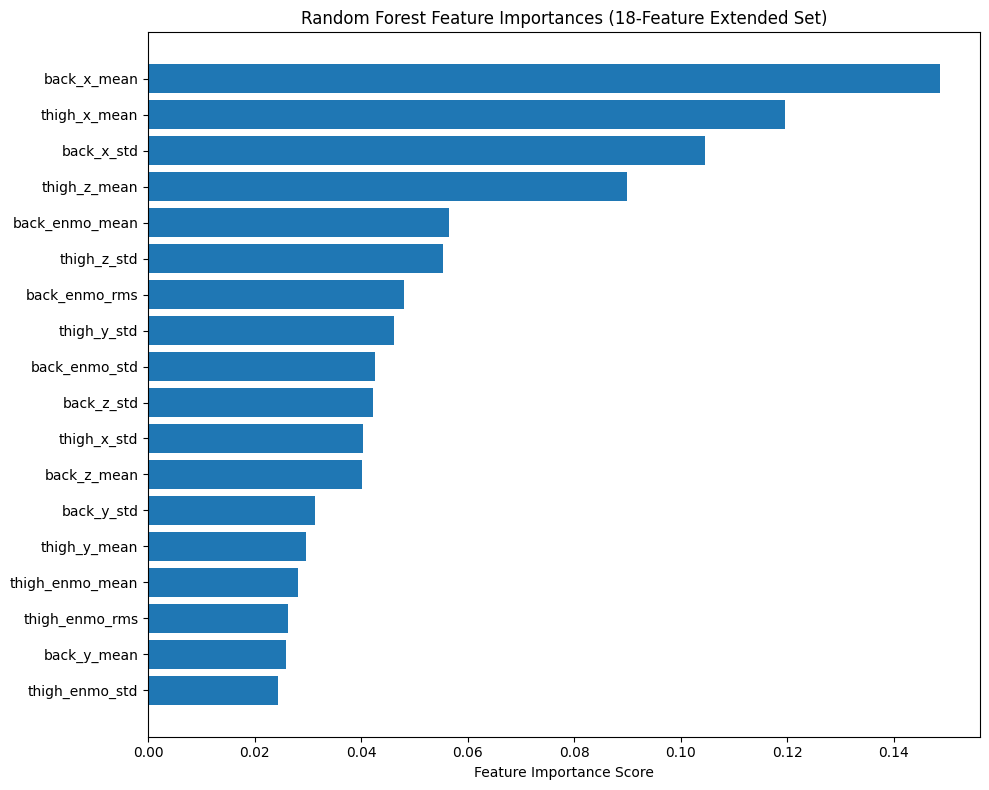

In [ ]:
feature_names = [
    "back_x_mean", "back_x_std",
    "back_y_mean", "back_y_std",
    "back_z_mean", "back_z_std",
    "thigh_x_mean", "thigh_x_std",
    "thigh_y_mean", "thigh_y_std",
    "thigh_z_mean", "thigh_z_std",
    "back_enmo_mean", "back_enmo_std", "back_enmo_rms",
    "thigh_enmo_mean", "thigh_enmo_std", "thigh_enmo_rms"
]

importances = rf_final.feature_importances_

# Sort features by importance
indices = np.argsort(importances)
sorted_features = np.array(feature_names)[indices]
sorted_importances = importances[indices]

# Plot
plt.figure(figsize=(10, 8))
plt.barh(sorted_features, sorted_importances)
plt.xlabel("Feature Importance Score")
plt.title("Random Forest Feature Importances (18-Feature Extended Set)")
plt.tight_layout()
plt.show()

CNN (Deep Learning)

In [35]:
tf.random.set_seed(42)

# Label encoding 
unique_labels = np.unique(y_train_full)          
label_to_idx = {lab: i for i, lab in enumerate(unique_labels)}
idx_to_label = {i: lab for lab, i in label_to_idx.items()}

def encode_labels(y):
    return np.vectorize(label_to_idx.get)(y)

def decode_labels(y_idx):
    return np.vectorize(idx_to_label.get)(y_idx)

y_train_cnn = encode_labels(y_train)
y_val_cnn   = encode_labels(y_val)
y_test_cnn  = encode_labels(y_test)

num_classes = len(unique_labels)
input_shape = X_train.shape[1:]   

# Channel-wise standardisation 
train_mean = X_train.mean(axis=(0, 1), keepdims=True)
train_std  = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train_cnn = (X_train - train_mean) / train_std
X_val_cnn   = (X_val   - train_mean) / train_std
X_test_cnn  = (X_test  - train_mean) / train_std

# Class weights for imbalance 
class_weights_array = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=y_train_cnn
)
class_weights_cnn = {i: w for i, w in enumerate(class_weights_array)}
class_weights_cnn

{0: np.float64(0.9400490486651092),
 1: np.float64(3.029879597509534),
 2: np.float64(3.378009255392018),
 3: np.float64(1.1463353100586213),
 4: np.float64(0.2643738726871086),
 5: np.float64(2.0184729494327343),
 6: np.float64(6.25562688529662)}

In [ ]:
def evaluate_cnn(model, X, y_true_idx, split_name=""):
    # y_true_idx are 0..num_classes-1
    y_prob = model.predict(X, verbose=0)
    y_pred_idx = y_prob.argmax(axis=1)

    y_true = decode_labels(y_true_idx)
    y_pred = decode_labels(y_pred_idx)

    acc = accuracy_score(y_true, y_pred)
    print(f"\n=== {model.name} – {split_name} ===")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification report:")
    print(classification_report(y_true, y_pred))
    return y_pred

In [37]:
# CNN BASELINE (SIMPLIFIED)

def build_cnn_simple(input_shape, num_classes):
    model = tf.keras.Sequential([
        # Reduced filters for less feature extraction
        tf.keras.layers.Conv1D(16, kernel_size=3, padding="valid",
                               activation="relu", input_shape=input_shape),
        tf.keras.layers.Flatten(), 
        # Reduced Dense layer size
        tf.keras.layers.Dense(32, activation="relu"), 
        # REMOVED ACTIVATION from the final hidden dense layer to force linearity
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ], name="cnn_simple")
    return model


cnn_simple = build_cnn_simple(input_shape, num_classes)
cnn_simple.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

# Keep other training parameters as they are...
early_stop_simple = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_cnn_simple = cnn_simple.fit(
    X_train_cnn, y_train_cnn,
    validation_data=(X_val_cnn, y_val_cnn),
    epochs=20, # Low epochs to prevent over-training a simple model
    batch_size=256,
    class_weight=class_weights_cnn,
    callbacks=[early_stop_simple],
    verbose=1
)

_ = evaluate_cnn(cnn_simple, X_test_cnn, y_test_cnn, split_name="TEST (simple_simplified)")

d:\MLT Coursework\mlt\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1580/1580 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8676 - loss: 0.5604 - val_accuracy: 0.9087 - val_loss: 0.2602
Epoch 2/20
1580/1580 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8977 - loss: 0.4416 - val_accuracy: 0.9137 - val_loss: 0.2459
Epoch 3/20
1580/1580 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9034 - loss: 0.4173 - val_accuracy: 0.9155 - val_loss: 0.2401
Epoch 4/20
1580/1580 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9068 - loss: 0.4036 - val_accuracy: 0.9160 - val_loss: 0.2392
Epoch 5/20
1580/1580 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9087 - loss: 0.3952 - val_accuracy: 0.9173 - val_loss: 0.2368
Epoch 6/20
1580/1580 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9097 - loss: 0.3889 - val_accuracy: 0.9175 - val_loss: 0.2362
Epoch 7/20
1580/1580 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9108 - loss: 0.3844 - val_accuracy: 0.9172 - val_loss: 0.2368
Epoch 8/20
1580/1580 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9115 - loss: 0.3806 - 

Fine Tuned CNN

In [38]:
# FINE-TUNED CNN MODEL (Simplified and Stabilized with ELU)

def build_cnn_final_stabilized(input_shape, num_classes):
    # Hyperparameters for fine-tuning
    DENSE_DROPOUT_RATE = 0.3 # Reduced dropout to retain more learned features
    KERNEL_SIZE = 3 

    inputs = tf.keras.Input(shape=input_shape)

    # --- BLOCK 1: Focus on feature extraction (Higher Filters, ELU Activation) ---
    x = tf.keras.layers.Conv1D(filters=128, kernel_size=KERNEL_SIZE, padding="same")(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ELU()(x) # <-- Using ELU activation for better gradient flow
    x = tf.keras.layers.MaxPooling1D(pool_size=2)(x) 
    
    # --- BLOCK 2: Focus on abstract features ---
    x = tf.keras.layers.Conv1D(filters=256, kernel_size=KERNEL_SIZE, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ELU()(x)
    x = tf.keras.layers.MaxPooling1D(pool_size=2)(x) 
    
    # --- CLASSIFICATION HEAD ---
    # Global Average Pooling is robust and prevents large feature vectors
    x = tf.keras.layers.GlobalAveragePooling1D()(x) 
    
    # Single, strong Dense layer before output
    x = tf.keras.layers.Dense(256, activation="relu")(x) 
    x = tf.keras.layers.Dropout(DENSE_DROPOUT_RATE)(x) # Use less aggressive dropout
    
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="cnn_two_block_elu")
    return model


cnn_final = build_cnn_final_stabilized(input_shape, num_classes)

cnn_final.compile(
    # Learning rate remains low for stability
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4), 
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

# Use more patient training parameters (high patience and epochs)
early_stop_final = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10, # Increased patience to 10
    restore_best_weights=True
)

reduce_lr_final = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4, # Increased patience for LR reduction
    min_lr=1e-6
)

history_cnn_final = cnn_final.fit(
    X_train_cnn, y_train_cnn,
    validation_data=(X_val_cnn, y_val_cnn),
    epochs=60, # <-- Increased epochs for full convergence
    batch_size=256,
    class_weight=class_weights_cnn, 
    callbacks=[early_stop_final, reduce_lr_final],
    verbose=1
)

_ = evaluate_cnn(cnn_final, X_test_cnn, y_test_cnn, split_name="TEST")

Epoch 1/60
1580/1580 ━━━━━━━━━━━━━━━━━━━━ 35s 21ms/step - accuracy: 0.8863 - loss: 0.4922 - val_accuracy: 0.9155 - val_loss: 0.2364 - learning_rate: 3.0000e-04
Epoch 2/60
1580/1580 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.9083 - loss: 0.4036 - val_accuracy: 0.9203 - val_loss: 0.2189 - learning_rate: 3.0000e-04
Epoch 3/60
1580/1580 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.9121 - loss: 0.3805 - val_accuracy: 0.9232 - val_loss: 0.2088 - learning_rate: 3.0000e-04
Epoch 4/60
1580/1580 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.9140 - loss: 0.3664 - val_accuracy: 0.9233 - val_loss: 0.2073 - learning_rate: 3.0000e-04
Epoch 5/60
1580/1580 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.9158 - loss: 0.3545 - val_accuracy: 0.9250 - val_loss: 0.2014 - learning_rate: 3.0000e-04
Epoch 6/60
1580/1580 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.9166 - loss: 0.3468 - val_accuracy: 0.9239 - val_loss: 0.2058 - learning_rate: 3.0000e-04
Epoch 7/60
1580/1580 ━━━━━━━━━━━━━━━━━━━

Accuracy and Loss Plots


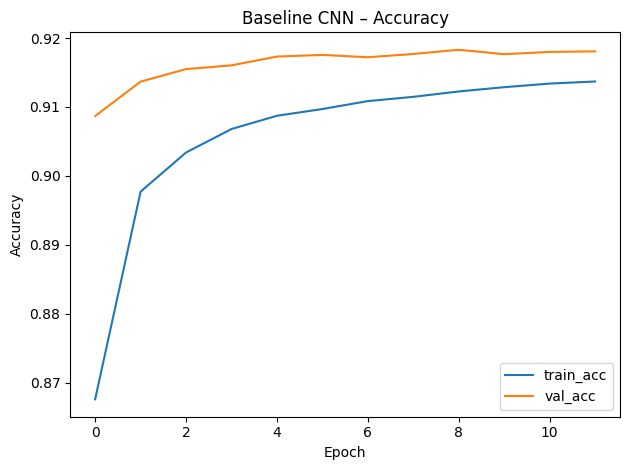

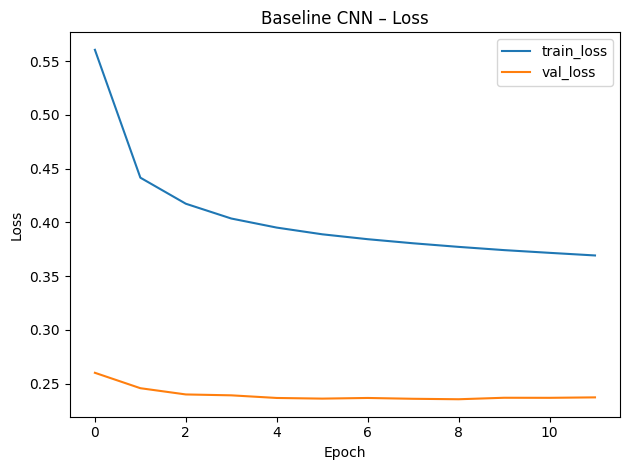

In [ ]:
# Accuracy
plt.figure()
plt.plot(history_cnn_simple.history["accuracy"], label="train_acc")
plt.plot(history_cnn_simple.history["val_accuracy"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN – Accuracy")
plt.legend()
plt.tight_layout()

# Loss
plt.figure()
plt.plot(history_cnn_simple.history["loss"], label="train_loss")
plt.plot(history_cnn_simple.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN – Loss")
plt.legend()
plt.tight_layout()

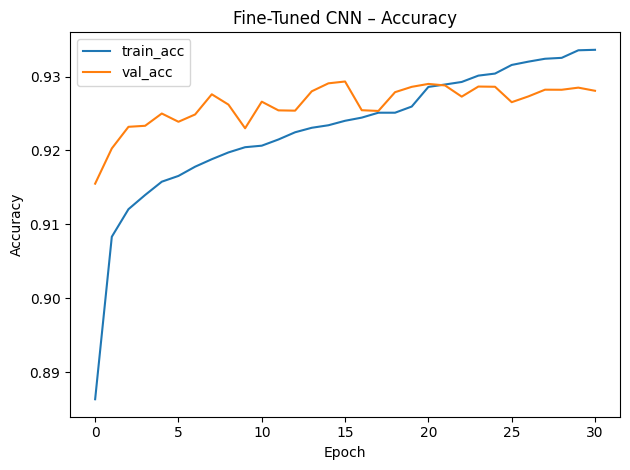

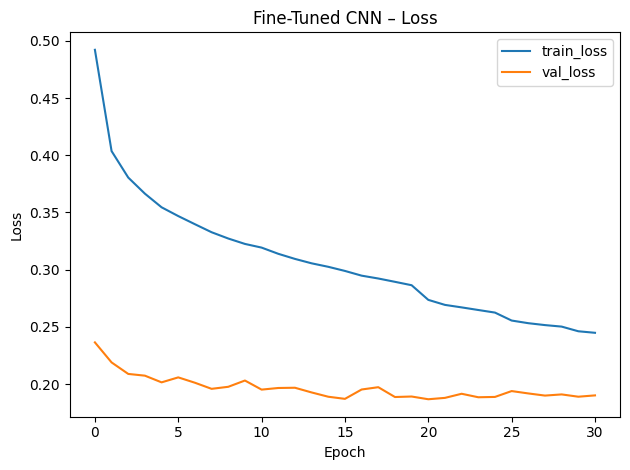

In [ ]:
# Accuracy
plt.figure()
plt.plot(history_cnn_final.history["accuracy"], label="train_acc")
plt.plot(history_cnn_final.history["val_accuracy"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Fine-Tuned CNN – Accuracy")
plt.legend()
plt.tight_layout()

# Loss
plt.figure()
plt.plot(history_cnn_final.history["loss"], label="train_loss")
plt.plot(history_cnn_final.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fine-Tuned CNN – Loss")
plt.legend()
plt.tight_layout()

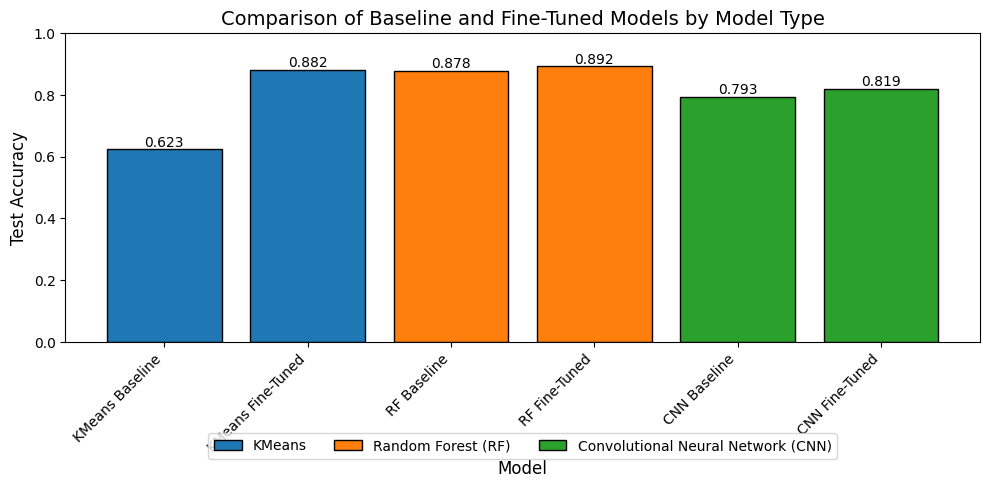

In [ ]:
model_names = [
    "KMeans Baseline",
    "KMeans Fine-Tuned",
    "RF Baseline",
    "RF Fine-Tuned",
    "CNN Baseline",
    "CNN Fine-Tuned"
]

accuracies = [
    0.6232,
    0.8816,
    0.8781,
    0.8923,
    0.7933,
    0.8186
]

color_map = plt.cm.tab10
color_kmeans = color_map(0)
color_rf = color_map(1)
color_cnn = color_map(2)

colors = [
    color_kmeans, color_kmeans,  
    color_rf, color_rf,          
    color_cnn, color_cnn         
]

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black')

for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{acc:.3f}",
        ha='center',
        fontsize=10
    )

plt.ylabel("Test Accuracy", fontsize=12)
plt.xlabel("Model", fontsize=12)
plt.title("Comparison of Baseline and Fine-Tuned Models by Model Type", fontsize=14)

plt.ylim(0, 1.0)
plt.xticks(rotation=45, ha="right")

legend_elements = [
    Patch(facecolor=color_kmeans, edgecolor='black', label='KMeans'),
    Patch(facecolor=color_rf, edgecolor='black', label='Random Forest (RF)'),
    Patch(facecolor=color_cnn, edgecolor='black', label='Convolutional Neural Network (CNN)')
]

plt.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.4), ncol=3)
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.savefig('model_comparison_by_type.png')

## Conclusion

Across all three modelling pipelines—KMeans, Random Forest, and CNN—the **fine-tuned Random Forest** achieved the strongest and most consistent performance.  

- **KMeans** improved substantially after feature expansion (0.6232 → 0.8816) but continued to cluster activities by movement intensity rather than behaviour, leading to poor separation for shuffling and stairs.  
- The **CNN models** captured temporal structure directly from raw windows and improved with deeper convolutional blocks (0.7933 → 0.8186), but still struggled with transitional and intensity-overlapping activities.  
- The **fine-tuned Random Forest** obtained the highest accuracy (**0.8923**) and met all required addendum thresholds for non-exempt classes. It generalised well across unseen subjects, required minimal computational resources, and maintained stable error behaviour.

**Overall, the fine-tuned Random Forest is the recommended model for deployment**, offering the best balance of accuracy, interpretability, efficiency, and robustness for real-world activity-recognition settings using wearable sensor data.
